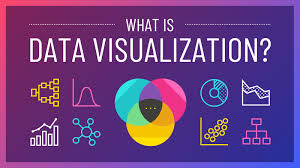

## 🥸 Exploratory data analysis

### 🎒 Packages

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
pd.set_option('display.max_colwidth', None)
import random

---

### 🚙 Utilities

In [2]:
train_path = Path("..") / "data" / "train.csv"
# only used for final outputing (estimation on real data)
test_path = Path("..") / "data" / "test.csv"
# store
store_path = Path("..") / "data" / "store.csv"

In [3]:
pastel_colors = sns.color_palette("pastel")

def color():
    color = random.choice(pastel_colors)
    return color

---

### 📊 Data

#### 🫦 Problem of mixed types

In [29]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], )

/tmp/ipykernel_13008/3960130451.py:1: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], )


In [4]:
train = pd.read_csv(filepath_or_buffer=train_path, parse_dates=["Date"], low_memory=False)
test = pd.read_csv(filepath_or_buffer=test_path, parse_dates=["Date"])
store = pd.read_csv(filepath_or_buffer=store_path)

In [5]:
store.head(5)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
train.head(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [7]:
test.head(5)

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [46]:
test["Date"].describe()

count                  41088
mean     2015-08-24 12:00:00
min      2015-08-01 00:00:00
25%      2015-08-12 18:00:00
50%      2015-08-24 12:00:00
75%      2015-09-05 06:00:00
max      2015-09-17 00:00:00
Name: Date, dtype: object

---

### 🔚 int main() {
###    std:: cout << "Hello world!";
###    return 0;
### }

In [8]:
train_eda = train.copy(deep=True)
store_eda = store.copy(deep=True)

In [9]:
store_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [10]:
train_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


### 🏬 Understand the store and its properties

In [11]:
store_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### 🇻 How many stores in each store's type?

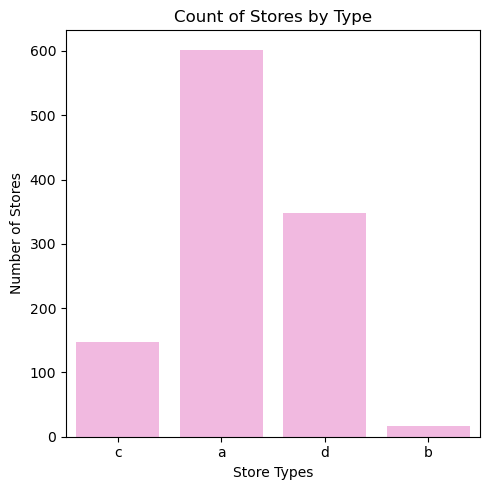

In [12]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(data=store_eda, x="StoreType", color=color(), ax=ax)

ax.set_xlabel("Store Types")
ax.set_ylabel("Number of Stores")
ax.set_title("Count of Stores by Type")

plt.tight_layout()
plt.show()

#### 🙉 Assortment type of all stores

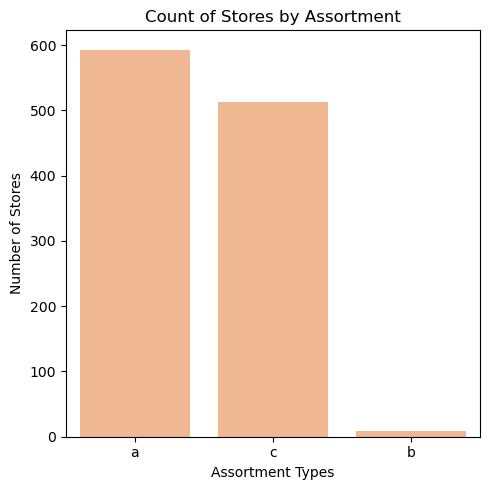

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(data=store_eda, x="Assortment", color=color(), ax=ax)

ax.set_xlabel("Assortment Types")
ax.set_ylabel("Number of Stores")
ax.set_title("Count of Stores by Assortment")

plt.tight_layout()
plt.show()

#### 🚦 Competition store's information

##### 😥 NAN

In [14]:
# Null detection
store_eda[store_eda["CompetitionDistance"].isna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [15]:
train_eda[train_eda["Store"].isin([291, 622, 879])]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
290,291,5,2015-07-31,10052,973,1,1,0,1
621,622,5,2015-07-31,6306,540,1,1,0,1
878,879,5,2015-07-31,6000,466,1,1,0,0
1405,291,4,2015-07-30,9030,883,1,1,0,1
1736,622,4,2015-07-30,5412,406,1,1,0,1
...,...,...,...,...,...,...,...,...,...
1015601,622,3,2013-01-02,4080,451,1,0,0,1
1015858,879,3,2013-01-02,3077,326,1,0,0,1
1016385,291,2,2013-01-01,0,0,0,0,a,1
1016716,622,2,2013-01-01,0,0,0,0,a,1


In [16]:
distance = store_eda.CompetitionDistance

distance.describe()

count     1112.000000
mean      5404.901079
std       7663.174720
min         20.000000
25%        717.500000
50%       2325.000000
75%       6882.500000
max      75860.000000
Name: CompetitionDistance, dtype: float64

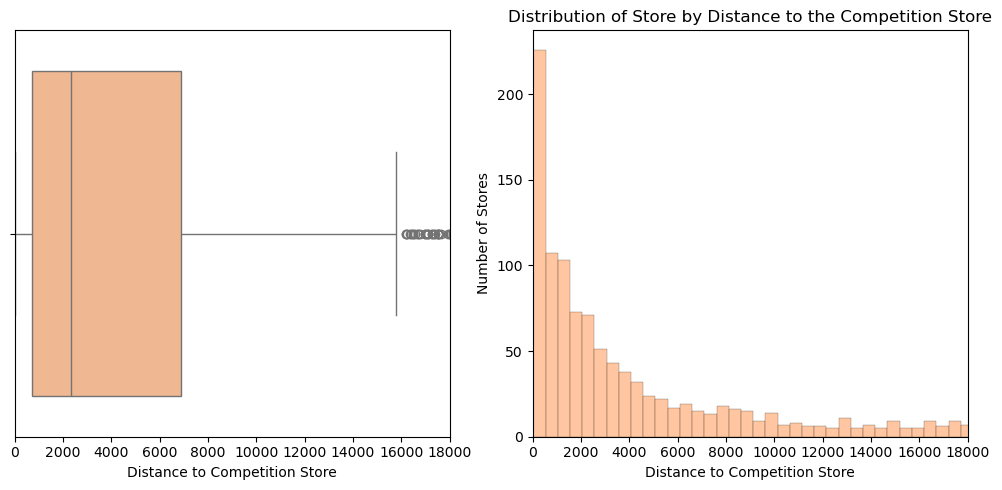

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.boxplot(data=store_eda, x="CompetitionDistance", color=c, ax=ax[0])

ax[0].set_xlabel("Distance to Competition Store")
ax[0].set_xlim((0, 18000))

sns.histplot(data=store_eda, x="CompetitionDistance", color=c, ax=ax[1], bins=150)

ax[1].set_xlabel("Distance to Competition Store")
ax[1].set_ylabel("Number of Stores")
ax[1].set_xlim((0, 18000))

plt.title("Distribution of Store by Distance to the Competition Store", loc="center")
plt.tight_layout()
plt.show()

##### 🇬🇧 The date the competition store was opened

In [18]:
store_eda.CompetitionOpenSinceYear.describe()

count     761.000000
mean     2008.668857
std         6.195983
min      1900.000000
25%      2006.000000
50%      2010.000000
75%      2013.000000
max      2015.000000
Name: CompetitionOpenSinceYear, dtype: float64

In [19]:
store_eda[store_eda.CompetitionOpenSinceYear.notna()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1108,1109,c,a,3490.0,4.0,2011.0,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"


In [20]:
store_eda.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


#### Ⓜ️ Long-term promotion's information

##### 📀 How many stores such that they have long-term promotion in the dataset?

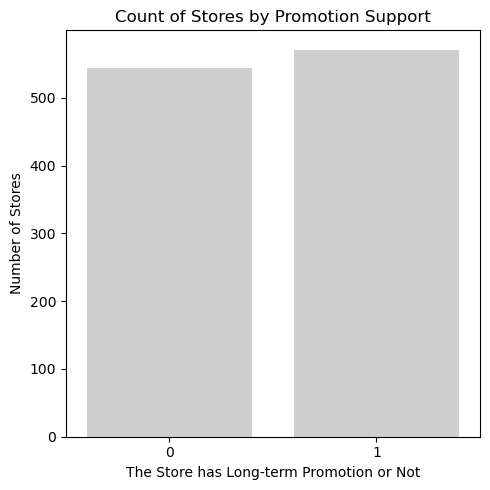

In [21]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.countplot(data=store_eda, x="Promo2", color=color(), ax=ax)

ax.set_xlabel("The Store has Long-term Promotion or Not")
ax.set_ylabel("Number of Stores")
ax.set_title("Count of Stores by Promotion Support")

plt.tight_layout()
plt.show()

In [22]:
store_eda[store_eda["Promo2"].notnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1110,1111,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


##### 😋 The interval count, most stores will have promotion interval in which month

In [23]:
store_eda["NumPromoMonths"] = store_eda["PromoInterval"].dropna().apply(lambda x: len(x.split(",")))

In [55]:
store_eda.head()
store_eda = store_eda.drop(columns=["NumPromoMonths"])

### 🔩 Merge the store and its daily sales

In [56]:
store_eda.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 🦋 The information of daily of a store on a specific day

In [57]:
train_eda.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [53]:
train_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[us]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  str           
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[us](1), int64(7), str(1)
memory usage: 69.8 MB


In [28]:
train_eda.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01


In [58]:
train_eda["Date"].describe()

count                       1017209
mean     2014-04-11 01:30:42.846062
min             2013-01-01 00:00:00
25%             2013-08-17 00:00:00
50%             2014-04-02 00:00:00
75%             2014-12-12 00:00:00
max             2015-07-31 00:00:00
Name: Date, dtype: object

#### ☄️ Combine/merge the two dataframes together, the sales' data will be linked with the store's information

In [59]:
merge_eda = train_eda.merge(right=store_eda, on="Store", how="left")

In [60]:
merge_eda.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [61]:
merge_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[us]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  str           
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  str           
 10  Assortment                 1017209 non-null  str           
 11  CompetitionDistance        1014567 non-null  flo

In [45]:
merge_eda["Date"].describe()

count                       1017209
mean     2014-04-11 01:30:42.846062
min             2013-01-01 00:00:00
25%             2013-08-17 00:00:00
50%             2014-04-02 00:00:00
75%             2014-12-12 00:00:00
max             2015-07-31 00:00:00
Name: Date, dtype: object

#### 📊 Open == 0 -> Sales == 0

In [65]:
merge_eda[merge_eda["Open"] == 0]["Sales"].describe()

count    172817.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64

In [ ]:
merge_eda_valid_sales= merge_eda[merge_eda["Open"] == 1]

In [67]:
len(merge_eda_valid_sales)

844392

#### 💦 Sales distribution

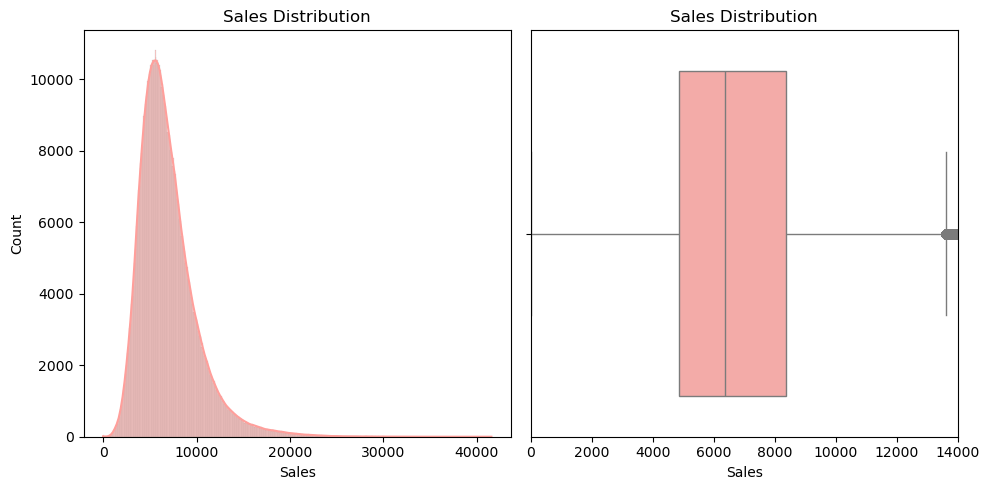

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.histplot(data=merge_eda_valid_sales, x="Sales", color=c, ax=axes[0], kde=True)

axes[0].set_xlabel("Sales")
# y is not the number of stores
# but the number of records for daily Sales
axes[0].set_title("Sales Distribution")

sns.boxplot(data=merge_eda_valid_sales, x="Sales", color=c, ax=axes[1])

axes[1].set_xlabel("Sales")
axes[1].set_title("Sales Distribution")
axes[1].set_xlim((-1, 14000))

plt.tight_layout()
plt.show()

In [79]:
merge_eda.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 🥼 Stores'types and sales

In [92]:
type_sales_df = merge_eda_valid_sales.groupby(by="StoreType")["Sales"].mean().reset_index()

In [93]:
type_sales_df.head()

,StoreType,Sales
0,a,6925.167661
1,b,10231.407505
2,c,6932.512755
3,d,6822.141881


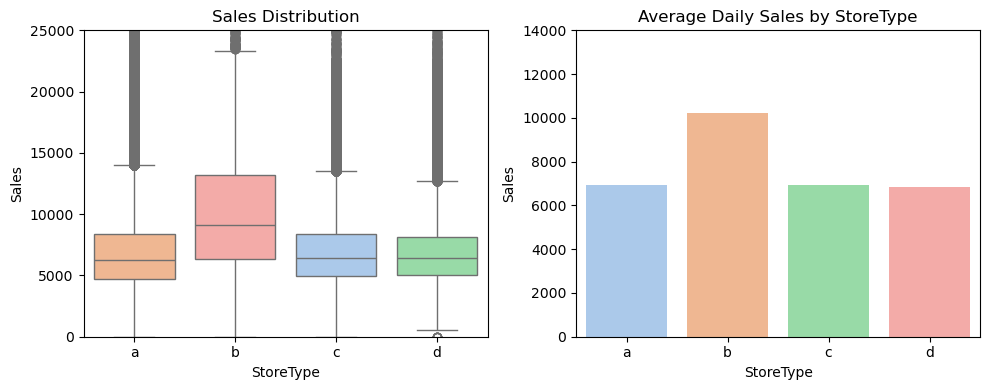

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
c = color()

sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="StoreType", ax=axes[0], hue="StoreType", order=["a", "b", "c", "d"], palette="pastel")

# y is not the number of stores
# but the number of records for daily Sales
axes[0].set_title("Sales Distribution")
axes[0].set_ylim((0, 25000))

sns.barplot(data=type_sales_df, x="StoreType", y="Sales", ax=axes[1], hue="StoreType", order=["a", "b", "c", "d"], palette="pastel")

axes[1].set_ylim((0, 14000))
axes[1].set_title("Average Daily Sales by StoreType")

plt.tight_layout()
plt.show()

In [121]:
store_eda.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [112]:
merge_eda_valid_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


---

#### 🧩 Assortment and Sales

In [116]:
assortment_sales_df = merge_eda_valid_sales.groupby(by="Assortment")["Sales"].mean().reset_index()

In [117]:
assortment_sales_df

,Assortment,Sales
0,a,6621.017039
1,b,8639.346322
2,c,7300.526339


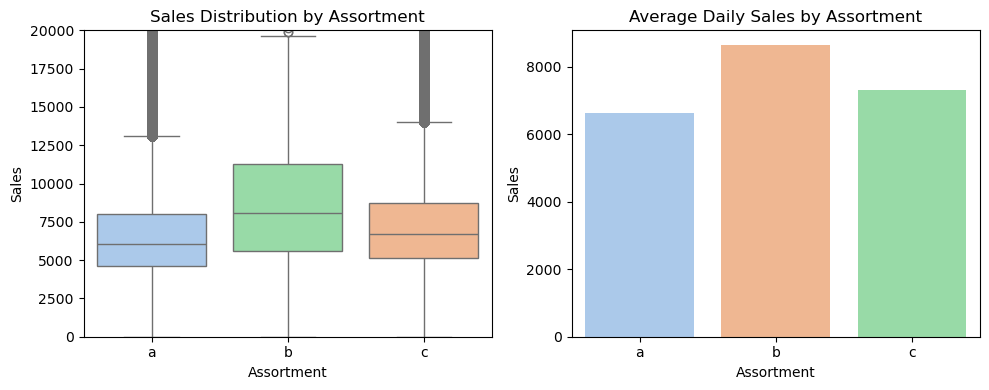

In [120]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
c = color()

sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="Assortment", ax=axes[0], hue="Assortment", order=["a", "b", "c"], palette="pastel")

# y is not the number of stores
# but the number of records for daily Sales
axes[0].set_title("Sales Distribution by Assortment")
axes[0].set_ylim((0, 20000))

sns.barplot(data=assortment_sales_df, x="Assortment", y="Sales", ax=axes[1], hue="Assortment", order=["a", "b", "c"], palette="pastel")

axes[1].set_ylim()
axes[1].set_title("Average Daily Sales by Assortment")

plt.tight_layout()
plt.show()

#### 🌵 CompetitionDistance and Sales

In [155]:
competition_dis_df = merge_eda_valid_sales.copy()

In [156]:
competition_dis_df.info()

<class 'pandas.DataFrame'>
Index: 844392 entries, 0 to 1017190
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844392 non-null  int64         
 1   DayOfWeek                  844392 non-null  int64         
 2   Date                       844392 non-null  datetime64[us]
 3   Sales                      844392 non-null  int64         
 4   Customers                  844392 non-null  int64         
 5   Open                       844392 non-null  int64         
 6   Promo                      844392 non-null  int64         
 7   StateHoliday               844392 non-null  str           
 8   SchoolHoliday              844392 non-null  int64         
 9   StoreType                  844392 non-null  str           
 10  Assortment                 844392 non-null  str           
 11  CompetitionDistance        842206 non-null  float64       
 12  Com

In [157]:
competition_dis_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [160]:
store_sales = competition_dis_df[competition_dis_df["Open"] == 1].groupby("Store").agg({
    "Sales": "mean",
    "CompetitionDistance": "first"
}).reset_index()

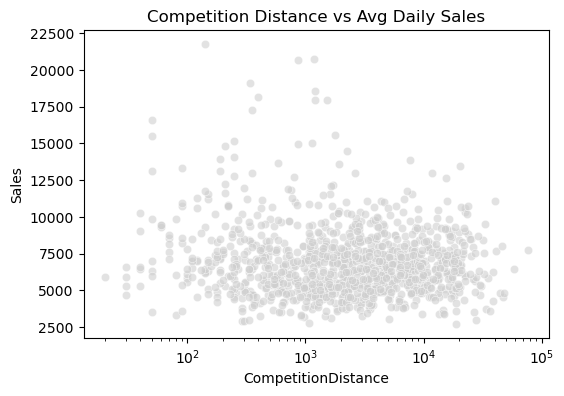

In [161]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=store_sales,
    x="CompetitionDistance",
    y="Sales",
    alpha=0.6,
    color=color(),
)

plt.xscale("log")
plt.title("Competition Distance vs Avg Daily Sales")
plt.show()

Text(0.5, 1.0, 'Trend between Competition Distance and Sales')

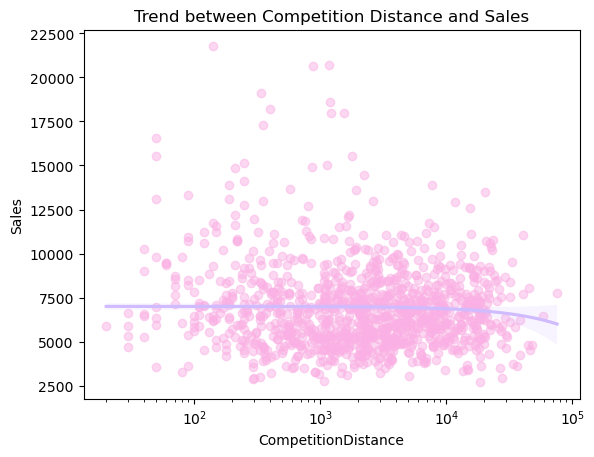

In [164]:
sns.regplot(
    data=store_sales,
    x="CompetitionDistance",
    y="Sales",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": color()},
    color=color(),
)

plt.xscale("log")
plt.title("Trend between Competition Distance and Sales")

In [165]:
merge_eda_valid_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 🙉 DayOfWeek and Daily Sales

In [174]:
dow_sales = merge_eda_valid_sales.groupby("DayOfWeek")["Sales"].mean().reset_index()

In [175]:
dow_sales.head()

,DayOfWeek,Sales
0,1,8216.073074
1,2,7088.113656
2,3,6728.122978
3,4,6767.310159
4,5,7072.677012


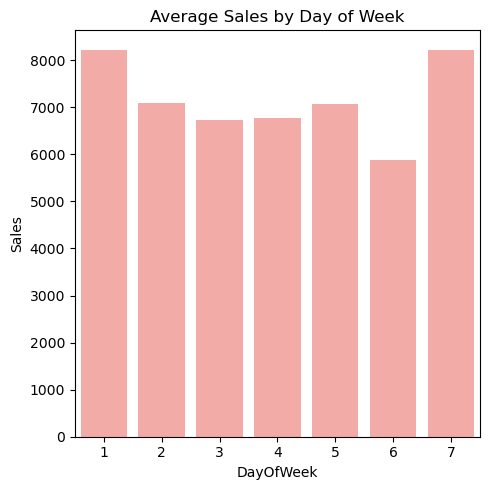

In [179]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(data=dow_sales, x="DayOfWeek", y="Sales", color=color(), ax=ax)


ax.set_title("Average Sales by Day of Week")

plt.tight_layout()
plt.show()

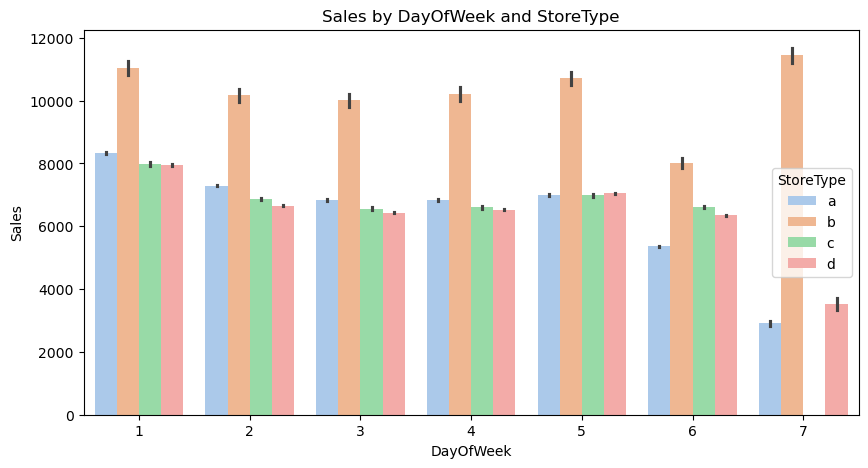

In [187]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="DayOfWeek",
    y="Sales",
    hue="StoreType",
    palette="pastel",
    hue_order=["a", "b", "c", "d"],
)

plt.title("Sales by DayOfWeek and StoreType")
plt.show()

In [195]:
store_c = merge_eda[merge_eda["StoreType"] == "c"]

In [196]:
store_c_on_sunday = store_c[store_c["DayOfWeek"] == 7]

In [197]:
store_c_on_sunday.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
5575,1,7,2015-07-26,0,0,0,0,0,0,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
5578,4,7,2015-07-26,0,0,0,0,0,0,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
5595,21,7,2015-07-26,0,0,0,0,0,0,c,c,550.0,10.0,1999.0,1,45.0,2009.0,"Jan,Apr,Jul,Oct"
5599,25,7,2015-07-26,0,0,0,0,0,0,c,a,430.0,4.0,2003.0,0,NaN,NaN,NaN
5608,34,7,2015-07-26,0,0,0,0,0,0,c,a,2240.0,9.0,2009.0,0,NaN,NaN,NaN


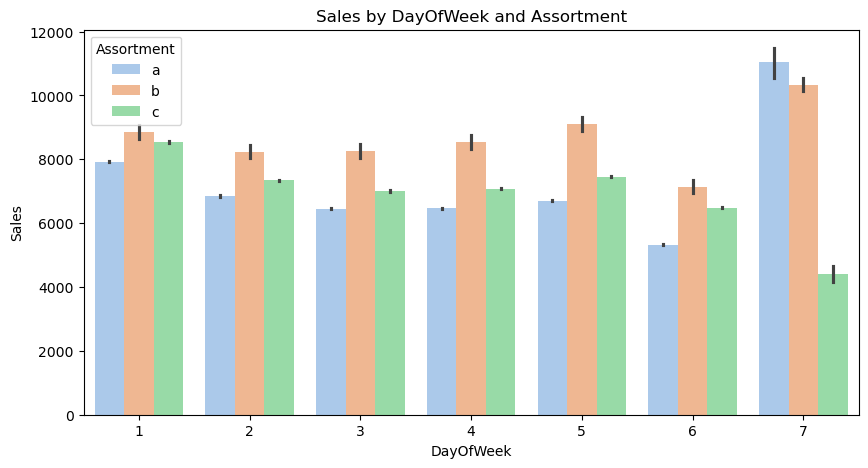

In [198]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="DayOfWeek",
    y="Sales",
    hue="Assortment",
    hue_order=["a", "b", "c"],
    palette="pastel",
)

plt.title("Sales by DayOfWeek and Assortment")
plt.show()

#### 🇩🇯 StateHoliday v.s Daily Sales

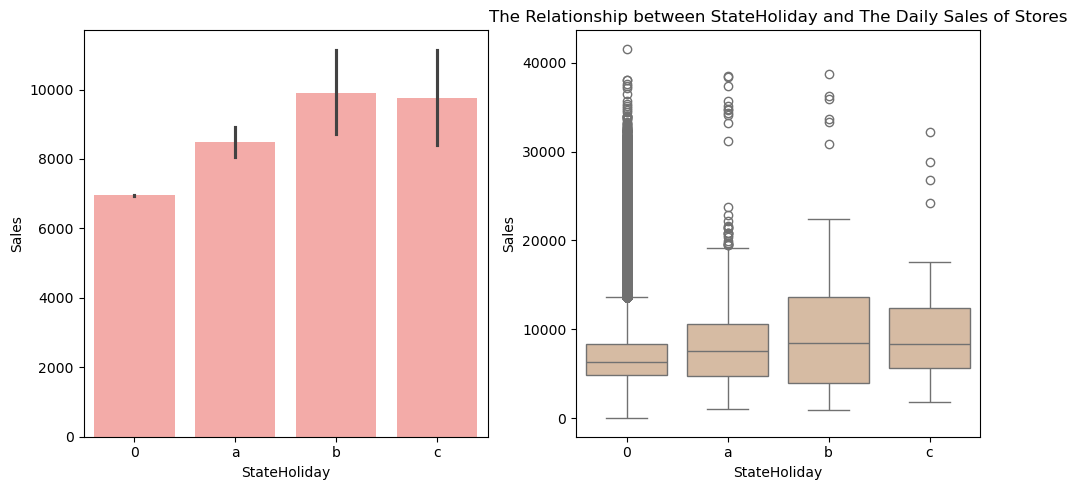

In [201]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=merge_eda_valid_sales, y="Sales", x="StateHoliday", ax=axes[0], order=["0", "a", "b", "c"], color=color())


sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="StateHoliday", ax=axes[1], order=["0", "a", "b", "c"], color=color())


plt.title("The Relationship between StateHoliday and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

#### 🌵 StateHoliday, StoreType v.s Sales

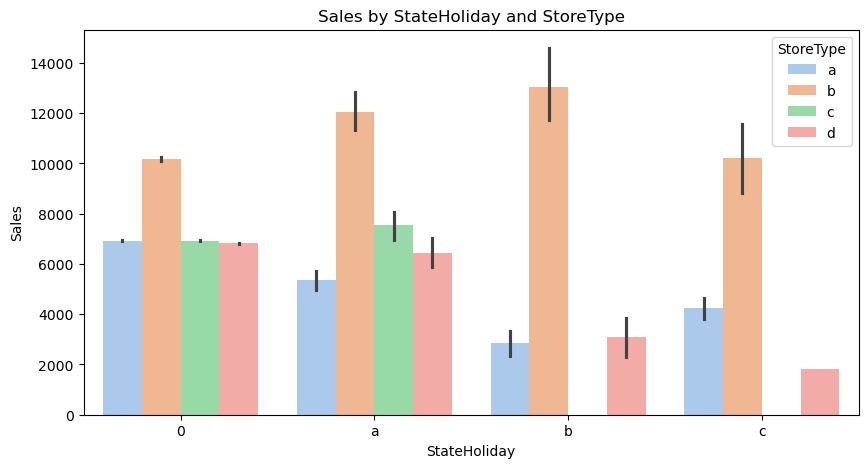

In [202]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="StateHoliday",
    y="Sales",
    hue="StoreType",
    hue_order=["a", "b", "c", "d"],
    palette="pastel",
)

plt.title("Sales by StateHoliday and StoreType")
plt.show()

#### 🧃StateHoliday, Assortment v.s Sales

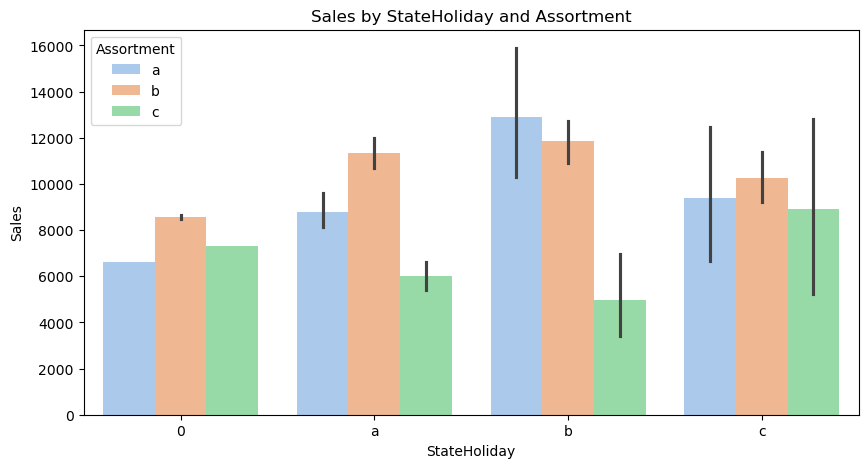

In [203]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=merge_eda_valid_sales,
    x="StateHoliday",
    y="Sales",
    hue="Assortment",
    hue_order=["a", "b", "c"],
    palette="pastel",
)

plt.title("Sales by StateHoliday and Assortment")
plt.show()

In [204]:
merge_eda_valid_sales.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


#### 💇 Promotion / promotion2 v.s Sales

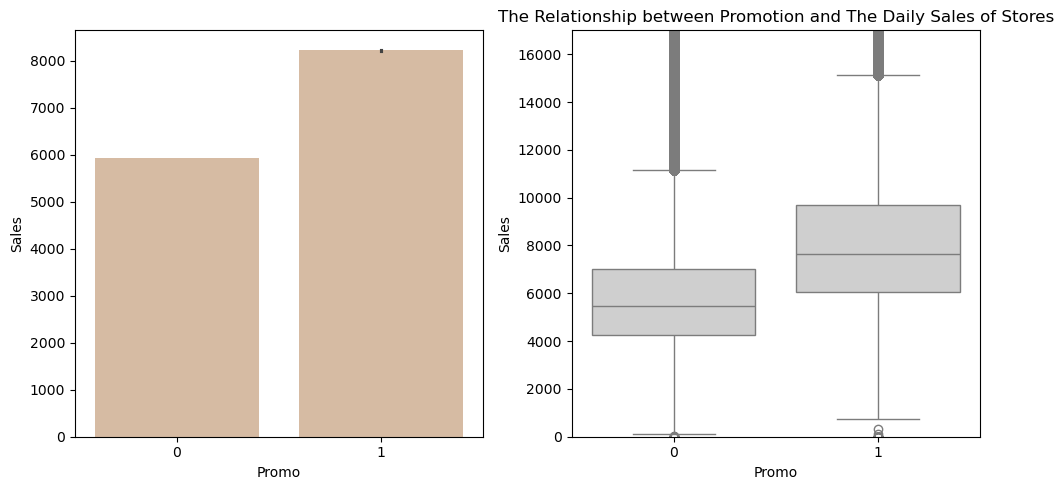

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=merge_eda_valid_sales, y="Sales", x="Promo", ax=axes[0], color=color())


sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="Promo", ax=axes[1], color=color())
axes[1].set_ylim((0, 17000))


plt.title("The Relationship between Promotion and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

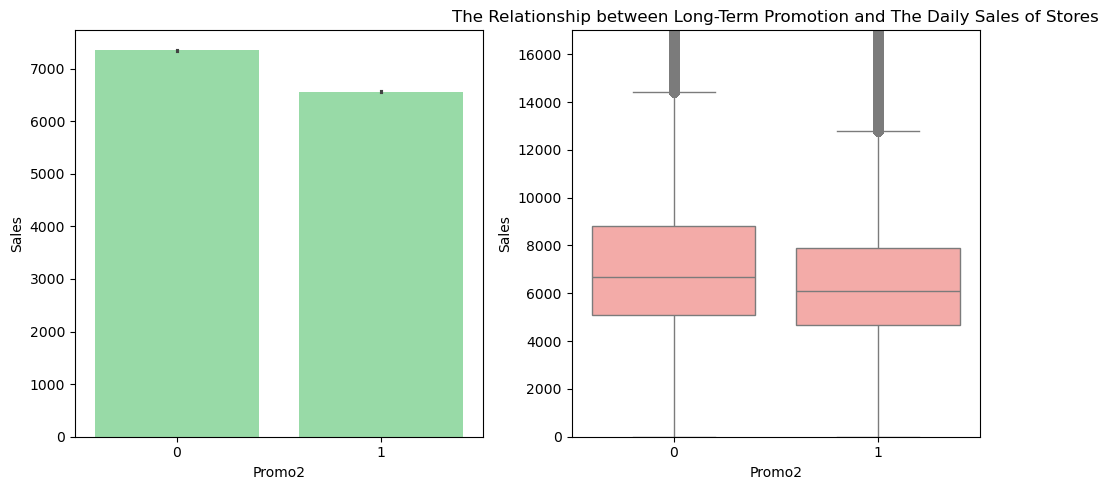

In [210]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=merge_eda_valid_sales, y="Sales", x="Promo2", ax=axes[0], color=color())


sns.boxplot(data=merge_eda_valid_sales, y="Sales", x="Promo2", ax=axes[1], color=color())
axes[1].set_ylim((0, 17000))


plt.title("The Relationship between Long-Term Promotion and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

##### 🈹 Promotion2 v.s Sales Time-aware, whether a day, a store has that Long-term promotion or not

In [215]:
promo2 = merge_eda_valid_sales.copy()

In [ ]:
promo2["Year"] = promo2["Date"].dt.year
promo2["Week"] = promo2["Date"].dt.isocalendar().week
promo2["Month"] = promo2["Date"].dt.month

To check whether a promotion has started at that time or not:
- If they have the promotion
- Current year > the year
- Current week >=

In [217]:
promo2["Promo2Started"] = (
    (promo2["Promo2"] == 1) &
    (
        (promo2["Year"] > promo2["Promo2SinceYear"]) |
        (
            (promo2["Year"] == promo2["Promo2SinceYear"]) &
            (promo2["Week"] >= promo2["Promo2SinceWeek"])
        )
    )
)

In [218]:
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sept", 10: "Oct", 11: "Nov", 12: "Dec"
}

promo2["MonthStr"] = promo2["Month"].map(month_map)

In [223]:
promo2["InPromoInterval"] = promo2.apply(
    lambda x: (
        isinstance(x["PromoInterval"], str) and
        x["MonthStr"] in x["PromoInterval"]
    ),
    axis=1
)

On that day, whether it has a long-term promotion active?

In [224]:
promo2["Promo2Active"] = (
    promo2["Promo2Started"] & promo2["InPromoInterval"]
).astype(int)

In [225]:
promo2.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Week,Month,Promo2Started,MonthStr,InPromoInterval,Promo2Active
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,NaN,NaN,2015,31,7,False,Jul,False,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,31,7,True,Jul,True,1
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,31,7,True,Jul,True,1
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,NaN,NaN,2015,31,7,False,Jul,False,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,NaN,NaN,2015,31,7,False,Jul,False,0


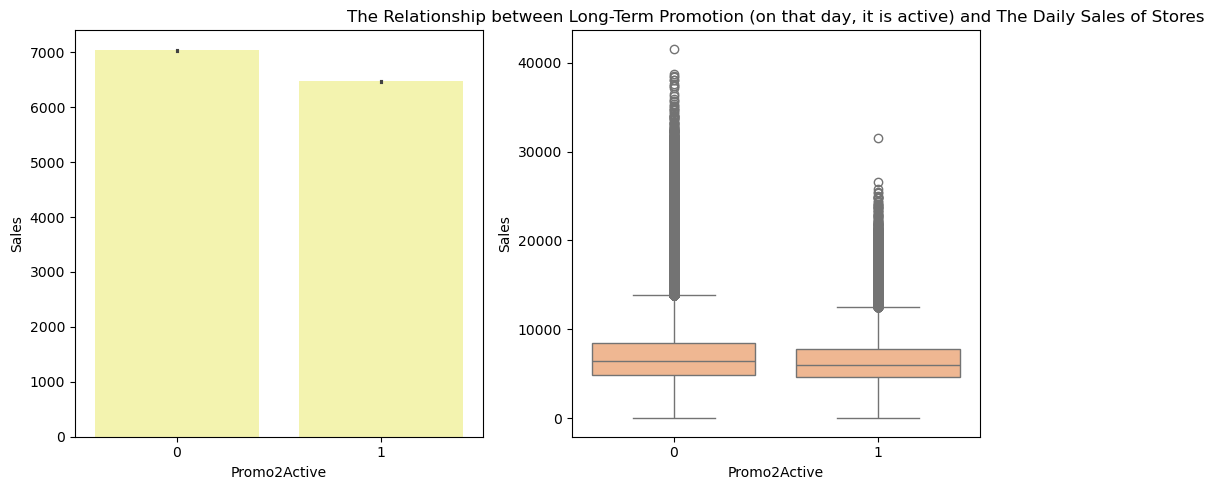

In [231]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
c = color()

sns.barplot(data=promo2, y="Sales", x="Promo2Active", ax=axes[0], color=color())


sns.boxplot(data=promo2, y="Sales", x="Promo2Active", ax=axes[1], color=color())


plt.title("The Relationship between Long-Term Promotion (on that day, it is active) and The Daily Sales of Stores")
plt.tight_layout()
plt.show()

#### 🥵 #Customers V.S Sales

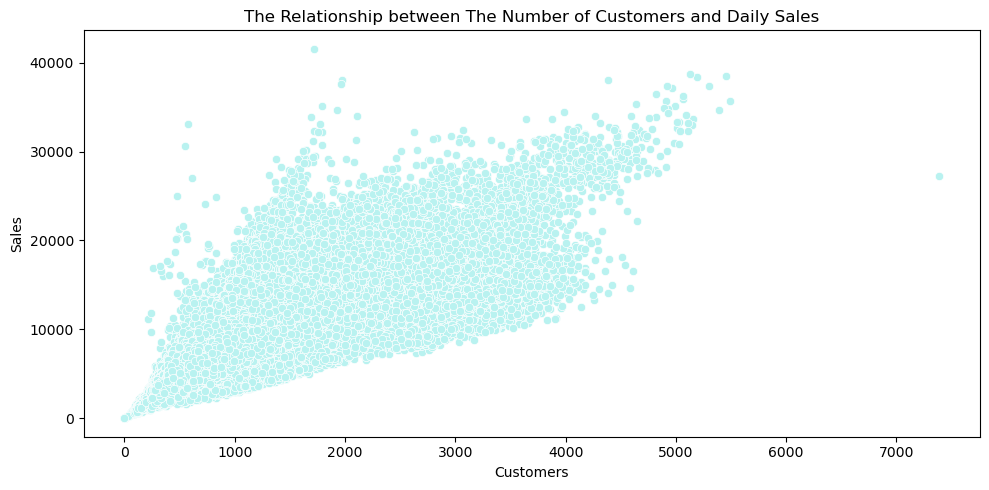

In [237]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
c = color()

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax, 
        color=color(),
        # hue="StoreType", 
        # palette="pastel", 
        # hue_order=["a", "b", "c", "d"]
    )


plt.title("The Relationship between The Number of Customers and Daily Sales")
plt.tight_layout()
plt.show()

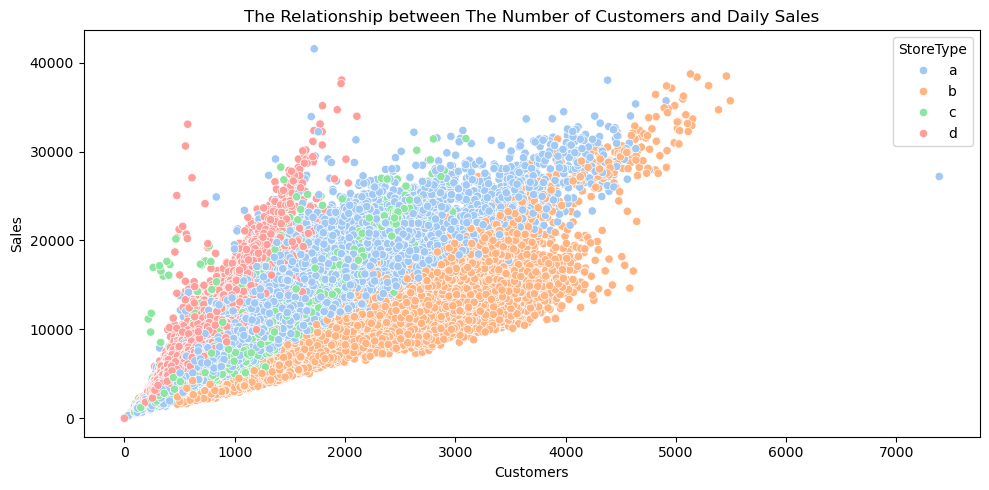

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
c = color()

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax, 
        hue="StoreType", 
        palette="pastel", 
        hue_order=["a", "b", "c", "d"]
    )


plt.title("The Relationship between The Number of Customers and Daily Sales")
plt.tight_layout()
plt.show()

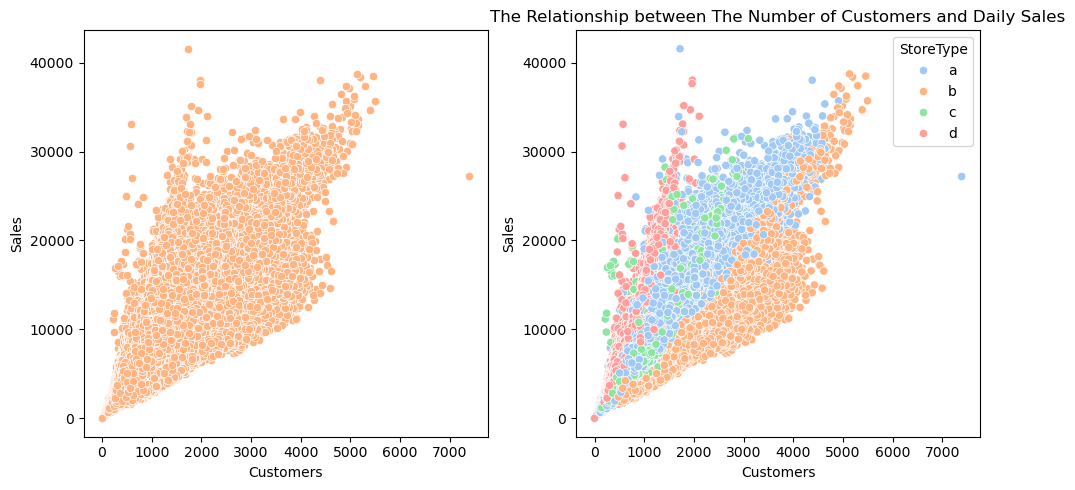

In [240]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

c = color()

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax[0], 
        color=color(),
        # hue="StoreType", 
        # palette="pastel", 
        # hue_order=["a", "b", "c", "d"]
        # ax=ax[0]
    )

sns.scatterplot(
        data=promo2, 
        y="Sales", 
        x="Customers", 
        ax=ax[1], 
        hue="StoreType", 
        palette="pastel", 
        hue_order=["a", "b", "c", "d"],
        # ax=ax[1]
    )

plt.title("The Relationship between The Number of Customers and Daily Sales")
plt.tight_layout()
plt.show()

##### 🤑 Money per customers V.S StoreType

In [242]:
money_df = merge_eda_valid_sales.copy()

In [243]:
money_df["SalesPerCustomer"] = money_df["Sales"] / money_df["Customers"]

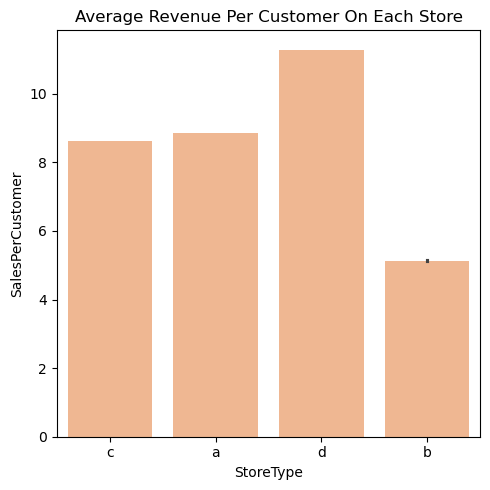

In [245]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(data=money_df, x="StoreType", y="SalesPerCustomer", color=color(), ax=ax)


ax.set_title("Average Revenue Per Customer On Each Store")

plt.tight_layout()
plt.show()